# Section 0: Trouble Shooting and Installations

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.1 MB/s eta 0:00:00


# Section 1: Data Loading and Exploration

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.18MB/s]
100%|██████████| 19.7M/19.7M [00:02<00:00, 9.16MB/s]


=== PneumoniaMNIST ===
Train: (4708, 28, 28), Labels: [1214 3494]
Val: (524, 28, 28), Labels: [135 389]
Test: (624, 28, 28), Labels: [234 390]

=== DermaMNIST ===
Train: (7007, 28, 28, 3), Labels: [ 228  359  769   80  779 4693   99]
Val: (1003, 28, 28, 3), Labels: [ 33  52 110  12 111 671  14]
Test: (2005, 28, 28, 3), Labels: [  66  103  220   23  223 1341   29]


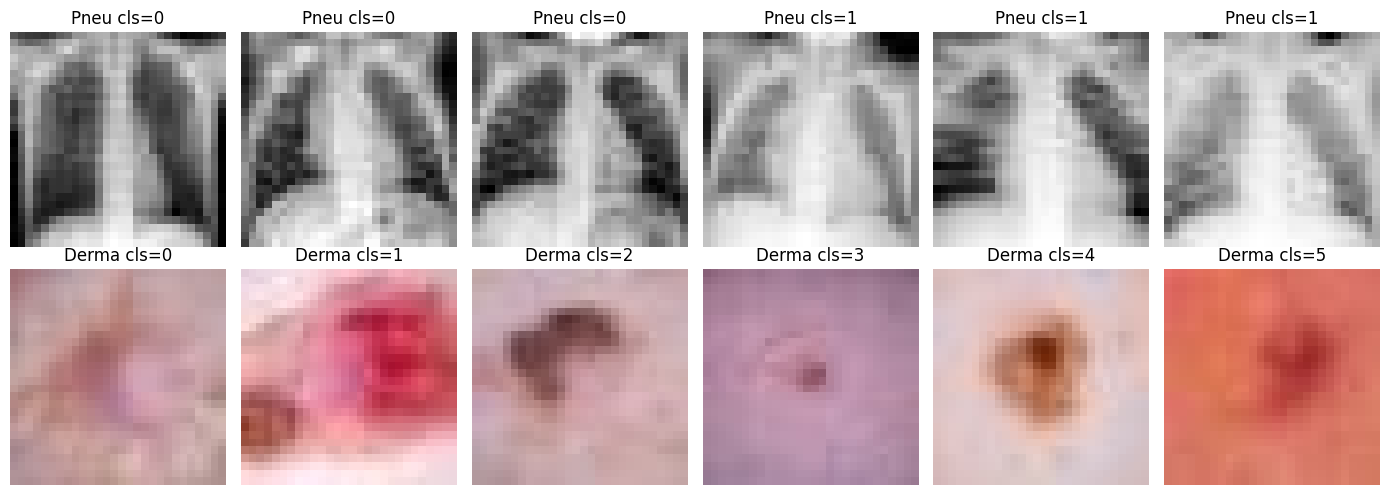

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import medmnist
from medmnist import PneumoniaMNIST, DermaMNIST

pneumonia_train = PneumoniaMNIST(split='train', download=True)
pneumonia_val = PneumoniaMNIST(split='val', download=True)
pneumonia_test = PneumoniaMNIST(split='test', download=True)

derma_train = DermaMNIST(split='train', download=True)
derma_val = DermaMNIST(split='val', download=True)
derma_test = DermaMNIST(split='test', download=True)

def extract_data(dataset):
    imgs = dataset.imgs
    labels = dataset.labels.flatten()
    return imgs, labels

pn_train_imgs, pn_train_labels = extract_data(pneumonia_train)
pn_val_imgs, pn_val_labels = extract_data(pneumonia_val)
pn_test_imgs, pn_test_labels = extract_data(pneumonia_test)

dm_train_imgs, dm_train_labels = extract_data(derma_train)
dm_val_imgs, dm_val_labels = extract_data(derma_val)
dm_test_imgs, dm_test_labels = extract_data(derma_test)

print("=== PneumoniaMNIST ===")
print(f"Train: {pn_train_imgs.shape}, Labels: {np.bincount(pn_train_labels)}")
print(f"Val: {pn_val_imgs.shape}, Labels: {np.bincount(pn_val_labels)}")
print(f"Test: {pn_test_imgs.shape}, Labels: {np.bincount(pn_test_labels)}")

print("\n=== DermaMNIST ===")
print(f"Train: {dm_train_imgs.shape}, Labels: {np.bincount(dm_train_labels)}")
print(f"Val: {dm_val_imgs.shape}, Labels: {np.bincount(dm_val_labels)}")
print(f"Test: {dm_test_imgs.shape}, Labels: {np.bincount(dm_test_labels)}")

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for cls in [0, 1]:
    idxs = np.where(pn_train_labels == cls)[0][:3]
    for j, idx in enumerate(idxs):
        ax = axes[0, cls * 3 + j]
        ax.imshow(pn_train_imgs[idx].squeeze(), cmap='gray')
        ax.set_title(f"Pneu cls={cls}")
        ax.axis('off')

for cls in range(6):
    idxs = np.where(dm_train_labels == cls)[0]
    ax = axes[1, cls]
    ax.imshow(dm_train_imgs[idxs[0]])
    ax.set_title(f"Derma cls={cls}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Section 2: Pre-processing and PCA pipeline

PneumoniaMNIST flattened: (4708, 784)
DermaMNIST flattened: (7007, 2352)


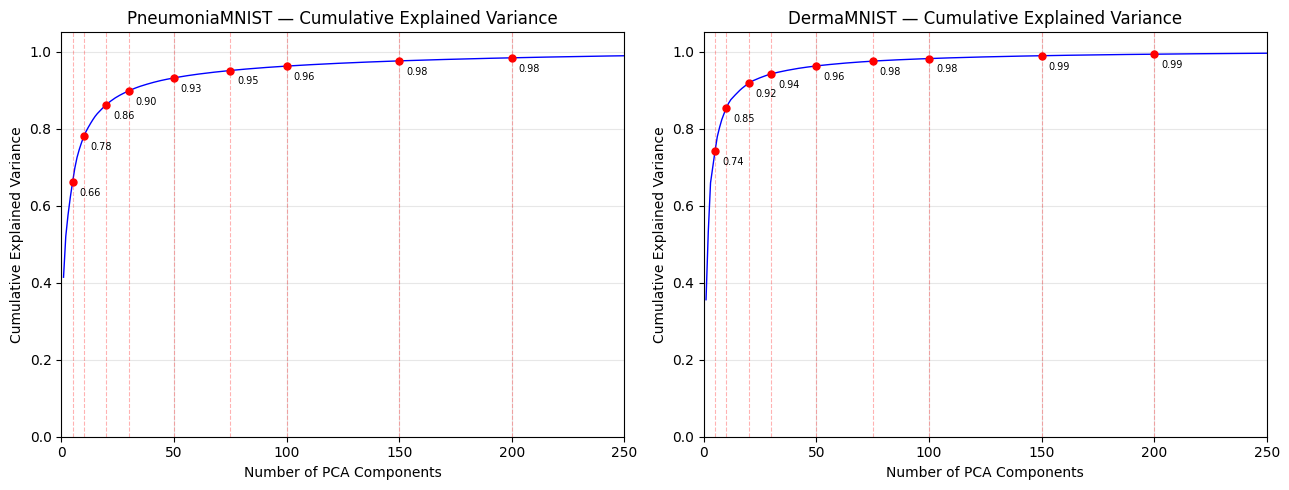

Quick check — PCA to 50 components: train (4708, 50), val (524, 50), test (624, 50)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def flatten_images(imgs):
    return imgs.reshape(imgs.shape[0], -1).astype(np.float64)

pn_train_flat = flatten_images(pn_train_imgs)
pn_val_flat = flatten_images(pn_val_imgs)
pn_test_flat = flatten_images(pn_test_imgs)

dm_train_flat = flatten_images(dm_train_imgs)
dm_val_flat = flatten_images(dm_val_imgs)
dm_test_flat = flatten_images(dm_test_imgs)

print(f"PneumoniaMNIST flattened: {pn_train_flat.shape}")
print(f"DermaMNIST flattened: {dm_train_flat.shape}")

pn_scaler = StandardScaler()
pn_train_scaled = pn_scaler.fit_transform(pn_train_flat)
pn_val_scaled = pn_scaler.transform(pn_val_flat)
pn_test_scaled = pn_scaler.transform(pn_test_flat)

dm_scaler = StandardScaler()
dm_train_scaled = dm_scaler.fit_transform(dm_train_flat)
dm_val_scaled = dm_scaler.transform(dm_val_flat)
dm_test_scaled = dm_scaler.transform(dm_test_flat)

pn_pca_full = PCA().fit(pn_train_scaled)
dm_pca_full = PCA().fit(dm_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pca_components_grid = [5, 10, 20, 30, 50, 75, 100, 150, 200]

for ax, pca_full, title in zip(axes, [pn_pca_full, dm_pca_full],
                                ['PneumoniaMNIST', 'DermaMNIST']):
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    ax.plot(range(1, len(cumvar) + 1), cumvar, 'b-', linewidth=1)
    for d in pca_components_grid:
        if d <= len(cumvar):
            ax.axvline(d, color='red', alpha=0.3, linestyle='--',
                       linewidth=0.8)
            ax.plot(d, cumvar[d - 1], 'ro', markersize=5)
            ax.annotate(f"{cumvar[d-1]:.2f}", (d, cumvar[d - 1]),
                        textcoords="offset points", xytext=(5, -10),
                        fontsize=7)
    ax.set_xlabel('Number of PCA Components')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.set_title(f'{title} — Cumulative Explained Variance')
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

def get_pca_data(n_components, train_scaled, val_scaled, test_scaled):
    pca = PCA(n_components=n_components, svd_solver='randomized',
              random_state=42)
    X_train = pca.fit_transform(train_scaled)
    X_val = pca.transform(val_scaled)
    X_test = pca.transform(test_scaled)
    return X_train, X_val, X_test, pca

X_tr, X_v, X_te, _ = get_pca_data(50, pn_train_scaled, pn_val_scaled, pn_test_scaled)
print(f"Quick check — PCA to 50 components: train {X_tr.shape}, val {X_v.shape}, test {X_te.shape}")

# Section 3: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

pca_components_grid = [5, 10, 20, 30, 50, 75, 100, 150, 200]
C_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 1e4]

def evaluate_classifier(clf, X_train, y_train, X_val, y_val, X_test,
                        y_test, multiclass=False):
    start = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    val_acc = accuracy_score(y_val, clf.predict(X_val))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    if multiclass:
        if hasattr(clf, 'predict_proba'):
            val_auc = roc_auc_score(y_val, clf.predict_proba(X_val),
                                    multi_class='ovr', average='macro')
            test_auc = roc_auc_score(y_test, clf.predict_proba(X_test),
                                     multi_class='ovr', average='macro')
        else:
            val_auc = test_auc = np.nan
        val_f1 = f1_score(y_val, clf.predict(X_val), average='macro')
        test_f1 = f1_score(y_test, clf.predict(X_test), average='macro')
    else:
        if hasattr(clf, 'predict_proba'):
            val_auc = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
            test_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
        else:
            val_auc = test_auc = np.nan
        val_f1 = f1_score(y_val, clf.predict(X_val))
        test_f1 = f1_score(y_test, clf.predict(X_test))

    return {
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'val_auc': val_auc, 'test_auc': test_auc,
        'val_f1': val_f1, 'test_f1': test_f1,
        'train_time': train_time
    }

lr_results_pn = []
print("=== Logistic Regression on PneumoniaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, pn_train_scaled,
                                      pn_val_scaled, pn_test_scaled)
    for C in C_grid:
        clf = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                                 max_iter=5000, random_state=42)
        metrics = evaluate_classifier(clf, X_tr, pn_train_labels,
                                      X_v, pn_val_labels,
                                      X_te, pn_test_labels, multiclass=False)
        metrics['pca_dim'] = d
        metrics['C'] = C
        lr_results_pn.append(metrics)
    print(f"  d={d:>3d} done")

lr_results_dm = []
print("\n=== Logistic Regression on DermaMNIST ===")
for d in pca_components_grid:
    X_tr, X_v, X_te, _ = get_pca_data(d, dm_train_scaled,
                                      dm_val_scaled, dm_test_scaled)
    for C in C_grid:
        clf = LogisticRegression(C=C, penalty='l2', solver='lbfgs',
                                 max_iter=5000,
                                 random_state=42, multi_class='multinomial')
        metrics = evaluate_classifier(clf, X_tr, dm_train_labels,
                                      X_v, dm_val_labels,
                                      X_te, dm_test_labels, multiclass=True)
        metrics['pca_dim'] = d
        metrics['C'] = C
        lr_results_dm.append(metrics)
    print(f"  d={d:>3d} done")

import pandas as pd
lr_df_pn = pd.DataFrame(lr_results_pn)
lr_df_dm = pd.DataFrame(lr_results_dm)

print("\n=== PneumoniaMNIST: Best configs by val accuracy ===")
print(lr_df_pn.sort_values('val_acc', ascending=False).head(5)[
    ['pca_dim', 'C', 'train_acc', 'val_acc', 'test_acc', 'val_auc', 'val_f1',
     'train_time']
].to_string(index=False))

print("\n=== DermaMNIST: Best configs by val accuracy ===")
print(lr_df_dm.sort_values('val_acc', ascending=False).head(5)[
    ['pca_dim', 'C', 'train_acc', 'val_acc', 'test_acc', 'val_auc', 'val_f1',
     'train_time']].to_string(index=False))

=== Logistic Regression on PneumoniaMNIST ===
  d=  5 done
  d= 10 done
  d= 20 done
  d= 30 done
  d= 50 done
  d= 75 done
  d=100 done
  d=150 done
  d=200 done

=== Logistic Regression on DermaMNIST ===
  d=  5 done
  d= 10 done
  d= 20 done
  d= 30 done
  d= 50 done
  d= 75 done
  d=100 done
  d=150 done
  d=200 done

=== PneumoniaMNIST: Best configs by val accuracy ===
 pca_dim     C  train_acc  val_acc  test_acc  val_auc   val_f1  train_time
     200 0.010   0.966865 0.959924  0.847756 0.991964 0.973111    0.384266
     200 0.001   0.955820 0.959924  0.836538 0.988632 0.973111    0.317763
     100 0.010   0.963679 0.959924  0.850962 0.991393 0.973042    0.500227
     150 0.001   0.955607 0.959924  0.838141 0.988594 0.973111    0.157966
     100 0.001   0.955183 0.959924  0.836538 0.988441 0.973111    0.276019

=== DermaMNIST: Best configs by val accuracy ===
 pca_dim       C  train_acc  val_acc  test_acc  val_auc   val_f1  train_time
      75    10.0   0.712573 0.696909  0.698254

In [ ]:
print("=== PneumoniaMNIST: Best C per PCA dimension ===")
for d in pca_components_grid:
    subset = lr_df_pn[lr_df_pn['pca_dim'] == d]
    best = subset.loc[subset['val_acc'].idxmax()]
    print(f"  d={d:>3d} | C={best['C']:>8.0e} | train_acc={best['train_acc']:.4f} | "
          f"val_acc={best['val_acc']:.4f} | test_acc={best['test_acc']:.4f} | "
          f"val_auc={best['val_auc']:.4f} | val_f1={best['val_f1']:.4f}")

print("\n=== DermaMNIST: Best C per PCA dimension ===")
for d in pca_components_grid:
    subset = lr_df_dm[lr_df_dm['pca_dim'] == d]
    best = subset.loc[subset['val_acc'].idxmax()]
    print(f"  d={d:>3d} | C={best['C']:>8.0e} | train_acc={best['train_acc']:.4f} | "
          f"val_acc={best['val_acc']:.4f} | test_acc={best['test_acc']:.4f} | "
          f"val_auc={best['val_auc']:.4f} | val_f1={best['val_f1']:.4f}")

=== PneumoniaMNIST: Best C per PCA dimension ===
  d=  5 | C=   1e-02 | train_acc=0.9102 | val_acc=0.9313 | test_acc=0.8381 | val_auc=0.9693 | val_f1=0.9545
  d= 10 | C=   1e-03 | train_acc=0.9284 | val_acc=0.9408 | test_acc=0.8093 | val_auc=0.9758 | val_f1=0.9604
  d= 20 | C=   1e-03 | train_acc=0.9390 | val_acc=0.9504 | test_acc=0.8269 | val_auc=0.9822 | val_f1=0.9666
  d= 30 | C=   1e-03 | train_acc=0.9486 | val_acc=0.9561 | test_acc=0.8333 | val_auc=0.9864 | val_f1=0.9705
  d= 50 | C=   1e-03 | train_acc=0.9526 | val_acc=0.9580 | test_acc=0.8365 | val_auc=0.9874 | val_f1=0.9718
  d= 75 | C=   1e-03 | train_acc=0.9531 | val_acc=0.9580 | test_acc=0.8365 | val_auc=0.9884 | val_f1=0.9718
  d=100 | C=   1e-03 | train_acc=0.9552 | val_acc=0.9599 | test_acc=0.8365 | val_auc=0.9884 | val_f1=0.9731
  d=150 | C=   1e-03 | train_acc=0.9556 | val_acc=0.9599 | test_acc=0.8381 | val_auc=0.9886 | val_f1=0.9731
  d=200 | C=   1e-03 | train_acc=0.9558 | val_acc=0.9599 | test_acc=0.8365 | val_auc=0.

# Section 4: Linear Discriminant Analysis